In [98]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

In [99]:
df = pd.read_excel(r"C:\Users\sande\OneDrive\Desktop\Telco-Customer-Churn-model\data\raw\Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [100]:
df.shape

(7043, 33)

In [101]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [102]:
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [103]:
df['Churn Label'].value_counts(normalize=True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [105]:
df.dtypes.value_counts()

object     24
int64       6
float64     3
Name: count, dtype: int64

In [106]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

Churn Reason    5174
dtype: int64

In [107]:
(df == "").sum().sort_values(ascending=False).head(10)


CustomerID    0
Count         0
Country       0
State         0
City          0
Zip Code      0
Lat Long      0
Latitude      0
Longitude     0
Gender        0
dtype: int64

In [108]:
(df.astype(str).apply(lambda col : col.str.strip()=="")).sum().sort_values(ascending=False).head(10)

Total Charges    11
CustomerID        0
Count             0
State             0
Country           0
Zip Code          0
Lat Long          0
Latitude          0
City              0
Gender            0
dtype: int64

In [109]:
df.duplicated().sum()

np.int64(0)

In [110]:
df['CustomerID'].duplicated().sum()

np.int64(0)

In [111]:
drop_columns = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "Churn Value",
    "Churn Score",
    "Churn Reason"
]

In [112]:
target = "Churn Label"

In [113]:
for col in df.columns:
    print(col , ":", df[col].nunique())

CustomerID : 7043
Count : 1
Country : 1
State : 1
City : 1129
Zip Code : 1652
Lat Long : 1652
Latitude : 1652
Longitude : 1651
Gender : 2
Senior Citizen : 2
Partner : 2
Dependents : 2
Tenure Months : 73
Phone Service : 2
Multiple Lines : 3
Internet Service : 3
Online Security : 3
Online Backup : 3
Device Protection : 3
Tech Support : 3
Streaming TV : 3
Streaming Movies : 3
Contract : 3
Paperless Billing : 2
Payment Method : 4
Monthly Charges : 1585
Total Charges : 6531
Churn Label : 2
Churn Value : 2
Churn Score : 85
CLTV : 3438
Churn Reason : 20


In [114]:
pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


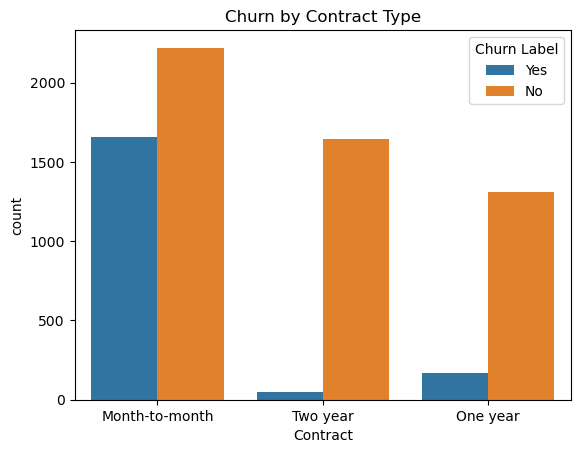

In [115]:
sns.countplot(
    data = df,
    x="Contract",
    hue="Churn Label"
)
plt.title("Churn by Contract Type")
plt.show()

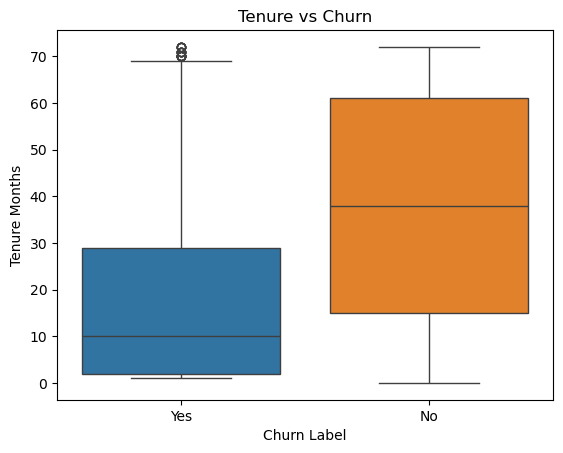

In [116]:
sns.boxplot(
    data = df,
    x="Churn Label",
    y = "Tenure Months",
    hue="Churn Label"
)
plt.title("Tenure vs Churn")
plt.show()

In [117]:
df.groupby("Churn Label")["Tenure Months"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


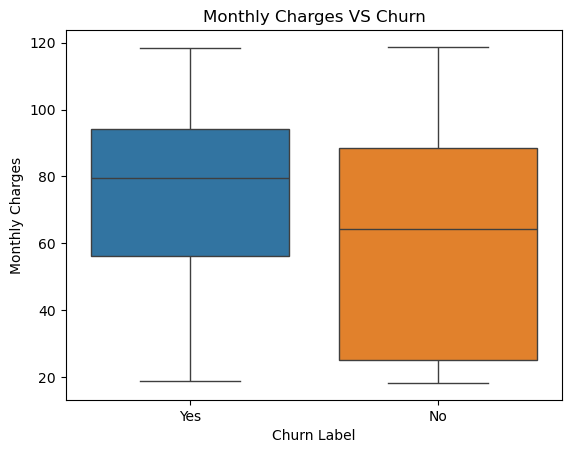

In [118]:
sns.boxplot(
    data = df,
    x="Churn Label",
    y="Monthly Charges",
    hue = "Churn Label"
)

plt.title("Monthly Charges VS Churn")
plt.show()

In [119]:
df.groupby("Churn Label")["Monthly Charges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


In [120]:
df['Total Charges']=pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)
df['Total Charges'].isnull().sum()

np.int64(11)

In [121]:
df['Tenure Months'].dtypes

dtype('int64')

In [122]:
pd.crosstab(
    df['Internet Service'],
    df['Churn Label'],
    normalize = "index"
)*100


Churn Label,No,Yes
Internet Service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


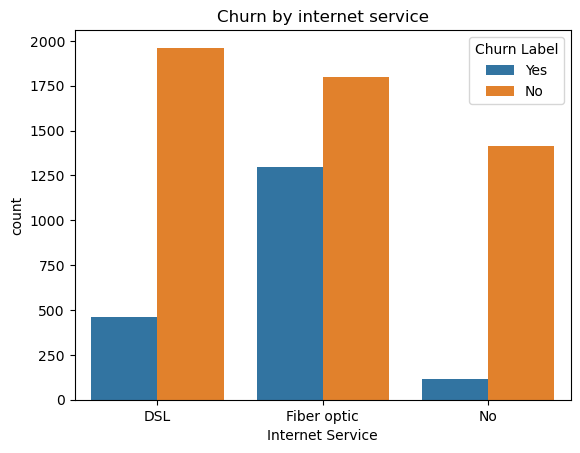

In [123]:
sns.countplot(
    data = df,
    x = "Internet Service",
    hue = "Churn Label"
)
plt.title("Churn by internet service")
plt.show()


In [124]:
pd.crosstab(
    df["Payment Method"],
    df["Churn Label"],
    normalize="index"
)*100

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


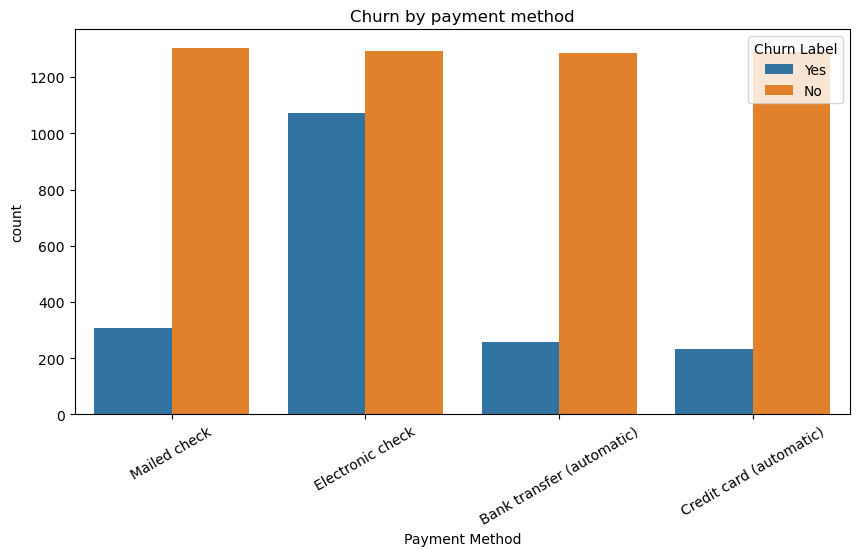

In [125]:
plt.figure(figsize=(10,5))
sns.countplot(
    data = df,
    x = "Payment Method",
    hue = "Churn Label"
)
plt.title("Churn by payment method")
plt.xticks(rotation=30)
plt.show()

In [126]:
pd.crosstab(
    df["Tech Support"],
    df["Churn Label"],
    normalize='index'
)*100

Churn Label,No,Yes
Tech Support,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [127]:
df[[
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]].describe()

,Tenure Months,Monthly Charges,Total Charges,CLTV
count,7043.000000,7043.000000,7032.000000,7043.000000
mean,32.371149,64.761692,2283.300441,4400.295755
std,24.559481,30.090047,2266.771362,1183.057152
min,0.000000,18.250000,18.800000,2003.000000
25%,9.000000,35.500000,401.450000,3469.000000
50%,29.000000,70.350000,1397.475000,4527.000000
75%,55.000000,89.850000,3794.737500,5380.500000
max,72.000000,118.750000,8684.800000,6500.000000


<Axes: >

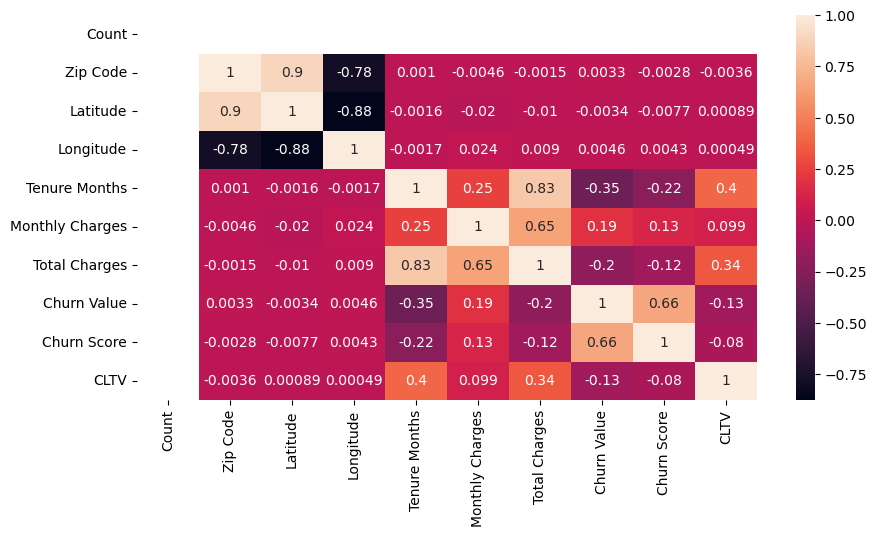

In [128]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [129]:
df[[
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV",
    "Churn Value"
]].corr()

,Tenure Months,Monthly Charges,Total Charges,CLTV,Churn Value
Tenure Months,1.000000,0.247900,0.825880,0.396406,-0.352229
Monthly Charges,0.247900,1.000000,0.651065,0.098693,0.193356
Total Charges,0.825880,0.651065,1.000000,0.341837,-0.199484
CLTV,0.396406,0.098693,0.341837,1.000000,-0.127463
Churn Value,-0.352229,0.193356,-0.199484,-0.127463,1.000000


In [130]:
df["Tenure Group"] = pd.cut(
    df["Tenure Months"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

In [131]:
pd.crosstab(
    df["Tenure Group"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Tenure Group,,
0-6 months,47.062795,52.937205
7-12 months,64.113475,35.886525
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49-72 months,90.486824,9.513176


* "Customers with shorter tenure have substantially higher observed churn rates in this dataset, while customers with longer tenure have lower observed churn rates." 


In [132]:
pd.crosstab(
    [df['Tenure Group'] , df['Contract']],
    df['Churn Label'],
    normalize='index'
)*100

Churn Label                          No        Yes
Tenure Group Contract                             
0-6 months   Month-to-month   44.798301  55.201699
             One year         89.743590  10.256410
             Two year        100.000000   0.000000
7-12 months  Month-to-month   58.003442  41.996558
             One year         89.411765  10.588235
             Two year        100.000000   0.000000
13-24 months Month-to-month   62.279512  37.720488
             One year         91.878173   8.121827
             Two year        100.000000   0.000000
25-48 months Month-to-month   67.082294  32.917706
             One year         89.382239  10.617761
             Two year         97.810219   2.189781
49-72 months Month-to-month   73.976608  26.023392
             One year         87.066246  12.933754
             Two year         96.674584   3.325416

In [133]:
pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [134]:
contact_tenure_churn = pd.crosstab(
    [df['Tenure Group'] ,  df['Contract']],
    df['Churn Label'],
    normalize='index'
)*100

contact_tenure_churn

Churn Label                          No        Yes
Tenure Group Contract                             
0-6 months   Month-to-month   44.798301  55.201699
             One year         89.743590  10.256410
             Two year        100.000000   0.000000
7-12 months  Month-to-month   58.003442  41.996558
             One year         89.411765  10.588235
             Two year        100.000000   0.000000
13-24 months Month-to-month   62.279512  37.720488
             One year         91.878173   8.121827
             Two year        100.000000   0.000000
25-48 months Month-to-month   67.082294  32.917706
             One year         89.382239  10.617761
             Two year         97.810219   2.189781
49-72 months Month-to-month   73.976608  26.023392
             One year         87.066246  12.933754
             Two year         96.674584   3.325416

In [135]:
pd.crosstab(
    [df['Tenure Group'] , df['Contract']] ,
    df['Churn Label']
)

Churn Label                    No  Yes
Tenure Group Contract                 
0-6 months   Month-to-month   633  780
             One year          35    4
             Two year          29    0
7-12 months  Month-to-month   337  244
             One year          76    9
             Two year          39    0
13-24 months Month-to-month   459  278
             One year         181   16
             Two year          90    0
25-48 months Month-to-month   538  264
             One year         463   55
             Two year         268    6
49-72 months Month-to-month   253   89
             One year         552   82
             Two year        1221   42

In [136]:
for col in df.columns:
    print(
        f"{col:25} | "
        f"dtype={str(df[col].dtype):10} | "
        f"unique={df[col].nunique():5}"
    )

CustomerID                | dtype=object     | unique= 7043
Count                     | dtype=int64      | unique=    1
Country                   | dtype=object     | unique=    1
State                     | dtype=object     | unique=    1
City                      | dtype=object     | unique= 1129
Zip Code                  | dtype=int64      | unique= 1652
Lat Long                  | dtype=object     | unique= 1652
Latitude                  | dtype=float64    | unique= 1652
Longitude                 | dtype=float64    | unique= 1651
Gender                    | dtype=object     | unique=    2
Senior Citizen            | dtype=object     | unique=    2
Partner                   | dtype=object     | unique=    2
Dependents                | dtype=object     | unique=    2
Tenure Months             | dtype=int64      | unique=   73
Phone Service             | dtype=object     | unique=    2
Multiple Lines            | dtype=object     | unique=    3
Internet Service          | dtype=object

In [137]:
drop_columns = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "Churn Value",
    "Churn Score",
    "Churn Reason",
    "Tenure Group"
]

In [138]:
geographic_columns = [
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude"
]

In [139]:
drop_columns = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Value",
    "Churn Score",
    "Churn Reason",
    "CLTV",
    "Tenure Group"
]

model_df = df.drop(columns=drop_columns)

model_df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes


In [140]:
model_df.shape

(7043, 20)

In [141]:
model_df.columns.to_list()

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label']

In [142]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [143]:
X = model_df.drop(columns=['Churn Label'])
y = model_df['Churn Label']

In [144]:
X.shape

(7043, 19)

In [145]:
y.shape

(7043,)

In [146]:
y.value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [147]:
y = y.map({'No': 0 , 'Yes' : 1})

In [148]:
y

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Label, Length: 7043, dtype: int64

In [149]:
X.isnull().sum().sort_values(ascending=False)

Total Charges        11
Senior Citizen        0
Gender                0
Partner               0
Dependents            0
Phone Service         0
Tenure Months         0
Internet Service      0
Online Security       0
Online Backup         0
Multiple Lines        0
Device Protection     0
Tech Support          0
Streaming Movies      0
Streaming TV          0
Contract              0
Paperless Billing     0
Payment Method        0
Monthly Charges       0
dtype: int64

In [150]:
df[df['Total Charges'].isnull()][
    ['Tenure Months',
     'Monthly Charges',
     'Total Charges',
     'Churn Label','Contract']
]

,Tenure Months,Monthly Charges,Total Charges,Churn Label,Contract
2234,0,52.55,NaN,No,Two year
2438,0,20.25,NaN,No,Two year
2568,0,80.85,NaN,No,Two year
2667,0,25.75,NaN,No,Two year
2856,0,56.05,NaN,No,Two year
4331,0,19.85,NaN,No,Two year
4687,0,25.35,NaN,No,Two year
5104,0,20.00,NaN,No,Two year
5719,0,19.70,NaN,No,One year
6772,0,73.35,NaN,No,Two year


In [151]:
df['Total Charges'] = df['Total Charges'].fillna(0)

In [152]:
df['Total Charges'].isnull().sum()

np.int64(0)

In [153]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [154]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [155]:
print("Training", X_train.shape)
print("Testing", X_test.shape)

Training (5634, 19)
Testing (1409, 19)


In [156]:
print("Train target distribution",y_train.value_counts(normalize=True)*100)
print("/nTest target distribution", y_test.value_counts(normalize=True)*100)

Train target distribution Churn Label
0    73.464679
1    26.535321
Name: proportion, dtype: float64
/nTest target distribution Churn Label
0    73.456352
1    26.543648
Name: proportion, dtype: float64


In [157]:
X_train.dtypes

Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
dtype: object

In [158]:
numeric_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]

categorical_features = [
    "Senior Citizen",
    "Gender",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method"
]

In [159]:
len(numeric_features), len(categorical_features)

(3, 16)

In [160]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [161]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [162]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

In [163]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [164]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [165]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Senior Citizen', 'Gender',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [166]:
y_pred = logistic_pipeline.predict(X_test)

In [167]:
y_proba = logistic_pipeline.predict_proba(X_test)[:, 1]
y_proba

array([0.07582216, 0.67292483, 0.10116256, ..., 0.18071085, 0.00541446,
       0.00234539])

In [168]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [169]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))
print("PR-AUC   :", average_precision_score(y_test, y_proba))

Accuracy : 0.8019872249822569
Precision: 0.6435045317220544
Recall   : 0.56951871657754
F1 Score : 0.6042553191489362
ROC-AUC  : 0.8487225193107547
PR-AUC   : 0.6449612341643484


In [170]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[917, 118],
       [161, 213]])

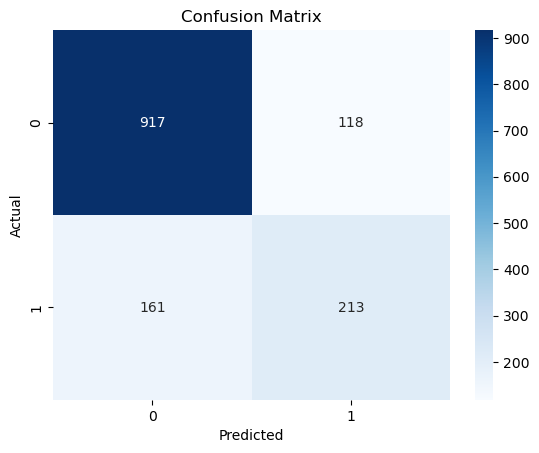

In [171]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [172]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [173]:
from sklearn.ensemble import RandomForestClassifier


In [174]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

In [175]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Senior Citizen', 'Gender',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('model',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [176]:
rf_pred = rf_pipeline.predict(X_test)

rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

In [177]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_proba))
print("PR-AUC   :", average_precision_score(y_test, rf_proba))

Accuracy : 0.7899219304471257
Precision: 0.6274509803921569
Recall   : 0.5133689839572193
F1 Score : 0.5647058823529412
ROC-AUC  : 0.8332338732594486
PR-AUC   : 0.6236862738300647


In [178]:
print(classification_report(
    y_test,
    rf_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.63      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



For this particular train/test split and these current configurations, Random Forest is performing worse than your Logistic Regression baseline on every reported metric.

That's useful information.

It tells us:

"More complex" does not automatically mean "better."

*The current Random Forest configuration performs worse than our Logistic Regression baseline on this evaluation split.*

In [179]:
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Senior Citizen', 'Gender',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            random_state=42))])

| Model               | Accuracy | Precision | Recall | F1   | ROC-AUC | PR-AUC |
|---------------------|----------|-----------|--------|------|---------|--------|
| Logistic Regression | 0.8020   | 0.6435    | 0.5695 | 0.6043 | 0.8487 | 0.6450 |
| Random Forest       | 0.7899   | 0.6275    | 0.5134 | 0.5647 | 0.8332 | 0.6237 |
| Gradient Boosting   | ?        | ?         | ?      | ?      | ?       | ?      |

In [180]:
gb_pred = gb_pipeline.predict(X_test)
gb_proba = gb_pipeline.predict_proba(X_test)[:, 1]

In [181]:
print("Accuracy :", accuracy_score(y_test, gb_pred))
print("Precision:", precision_score(y_test, gb_pred))
print("Recall   :", recall_score(y_test, gb_pred))
print("F1 Score :", f1_score(y_test, gb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, gb_proba))
print("PR-AUC   :", average_precision_score(y_test, gb_proba))

Accuracy : 0.8090844570617459
Precision: 0.6791808873720137
Recall   : 0.5320855614973262
F1 Score : 0.5967016491754122
ROC-AUC  : 0.8533118912914309
PR-AUC   : 0.6732610486001834


In [182]:
print(classification_report(
    y_test,
    gb_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.68      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [183]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [184]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [185]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [186]:
lr_cv = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [187]:
lr_cv_results = pd.DataFrame({
    "Metric": scoring.keys(),
    "Mean": [
        lr_cv["test_accuracy"].mean(),
        lr_cv["test_precision"].mean(),
        lr_cv["test_recall"].mean(),
        lr_cv["test_f1"].mean(),
        lr_cv["test_roc_auc"].mean(),
        lr_cv["test_pr_auc"].mean()
    ],
    "Std": [
        lr_cv["test_accuracy"].std(),
        lr_cv["test_precision"].std(),
        lr_cv["test_recall"].std(),
        lr_cv["test_f1"].std(),
        lr_cv["test_roc_auc"].std(),
        lr_cv["test_pr_auc"].std()
    ]
})

lr_cv_results

,Metric,Mean,Std
0,accuracy,0.811681,0.011479
1,precision,0.666257,0.023635
2,recall,0.581940,0.042146
3,f1,0.620606,0.029085
4,roc_auc,0.858930,0.012563
5,pr_auc,0.680011,0.020510


In [188]:
gb_cv = cross_validate(
    gb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [189]:
gb_cv_results = pd.DataFrame({
    "Metric": scoring.keys(),
    "Mean": [
        gb_cv["test_accuracy"].mean(),
        gb_cv["test_precision"].mean(),
        gb_cv["test_recall"].mean(),
        gb_cv["test_f1"].mean(),
        gb_cv["test_roc_auc"].mean(),
        gb_cv["test_pr_auc"].mean()
    ],
    "Std": [
        gb_cv["test_accuracy"].std(),
        gb_cv["test_precision"].std(),
        gb_cv["test_recall"].std(),
        gb_cv["test_f1"].std(),
        gb_cv["test_roc_auc"].std(),
        gb_cv["test_pr_auc"].std()
    ]
})

gb_cv_results

,Metric,Mean,Std
0,accuracy,0.808309,0.011900
1,precision,0.673590,0.028676
2,recall,0.539130,0.028489
3,f1,0.598659,0.026236
4,roc_auc,0.863888,0.010830
5,pr_auc,0.689427,0.020285


# Hyperparameter tuning

In [190]:
from sklearn.model_selection import RandomizedSearchCV

lr_param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"],
    "model__class_weight": [None, "balanced"]
}

lr_search = RandomizedSearchCV(
    estimator=logistic_pipeline,
    param_distributions=lr_param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lr_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Tenure '
                                                                                'Months',
                                                                                'Monthly '
                                                                                'Charges',
                                                                                'Total '
                                                                                'Charges']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImp...
                                                                                'Support',
                                                                                'Streaming '
                                                                                'TV',
                                                                                'Streaming '
                                                                                'Movies',
                                                                                'Contract',
                                                                                'Paperless '
                                                                                'Billing',
                                                                                'Payment '
                                                                                'Method'])])),
                                             ('model',
                                              LogisticRegression(max_iter=1000,
                                                                 random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'model__C': [0.001, 0.01, 0.1, 1, 10,
                                                     100],
                                        'model__class_weight': [None,
                                                                'balanced'],
                                        'model__solver': ['liblinear',
                                                          'lbfgs']},
                   random_state=42, scoring='roc_auc', verbose=1)

In [191]:
print("Best Parameters:")
print(lr_search.best_params_)

print("\nBest CV ROC-AUC:")
print(lr_search.best_score_)

Best Parameters:
{'model__solver': 'lbfgs', 'model__class_weight': None, 'model__C': 100}

Best CV ROC-AUC:
0.8591398393971292


In [192]:
gb_param_grid = {
    "model__n_estimators": [50, 100, 150, 200, 300],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__subsample": [0.8, 1.0]
}

In [193]:
gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gb_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Tenure '
                                                                                'Months',
                                                                                'Monthly '
                                                                                'Charges',
                                                                                'Total '
                                                                                'Charges']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImp...
                                              GradientBoostingClassifier(learning_rate=0.05,
                                                                         random_state=42))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.01, 0.03,
                                                                 0.05, 0.1,
                                                                 0.2],
                                        'model__max_depth': [2, 3, 4, 5],
                                        'model__min_samples_leaf': [1, 2, 5,
                                                                    10],
                                        'model__min_samples_split': [2, 5, 10,
                                                                     20],
                                        'model__n_estimators': [50, 100, 150,
                                                                200, 300],
                                        'model__subsample': [0.8, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [194]:
print("Best Parameters:")
print(gb_search.best_params_)

print("\nBest CV ROC-AUC:")
print(gb_search.best_score_)

Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': 3, 'model__learning_rate': 0.05}

Best CV ROC-AUC:
0.86478102172312


In [195]:
best_gb = gb_search.best_estimator_